# Retrain with Full CPI Overlap (2017–2023)

The v2 model was trained on a small window (mid-2017 to 2019, ~58 rows).

Now we retrain on the full overlap between maize price data and CPI:
- **Train**: July 2017 to December 2023
- **Test**: January 2024 to April 2025 (16 months of recent, post-COVID data)

This gives the model a much larger training set while keeping an honest holdout
for benchmarking we can publish.


In [6]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "huggingface_hub"], check=True)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


CompletedProcess(args=['/Users/pascal/projects/east-africa-food-prices/.venv/bin/python', '-m', 'pip', 'install', 'huggingface_hub'], returncode=0)

In [7]:
import pandas as pd
from huggingface_hub import hf_hub_download

# Download datasets from HuggingFace
prices_path = hf_hub_download(
    repo_id="byabasaija/uganda-maize-prices",
    filename="uganda_maize_prices_owino.csv",
    repo_type="dataset",
)
cpi_path = hf_hub_download(
    repo_id="byabasaija/uganda-food-cpi",
    filename="maize_cpi_monthly.csv",
    repo_type="dataset",
)


maize_df = pd.read_csv(prices_path)
cpi_df = pd.read_csv(cpi_path).rename(columns={"maize_cpi": "food_cpi"})

# Merge on year + month
merged_clean = maize_df.merge(cpi_df, on=["year", "month"], how="inner")
merged_clean["date"] = pd.to_datetime(merged_clean[["year", "month"]].assign(day=15))

print(f"Rows after merge: {len(merged_clean)}")
print(f"Date range: {merged_clean['date'].min().date()} to {merged_clean['date'].max().date()}")
merged_clean[["date", "price", "food_cpi"]].head()

Rows after merge: 87
Date range: 2017-07-15 to 2025-04-15


,date,price,food_cpi
0,2017-07-15,1841.67,127.4615
1,2017-08-15,1783.33,112.9988
2,2017-09-15,1000.00,104.3758
3,2017-10-15,900.00,101.1602
4,2017-11-15,2217.00,93.6602


## Build Feature Matrix

In [10]:
import sys
sys.path.insert(0, "../food_prices_api")
from features import compute_features

prices_series = merged_clean["price"].tolist()
feature_rows = []
targets = []

for i in range(6, len(merged_clean)):
    past_prices = prices_series[i - 6 : i]
    row = merged_clean.iloc[i]
    feats = compute_features(past_prices, int(row["month"]), int(row["year"]))
    feats["food_cpi"] = row["food_cpi"]
    feature_rows.append(feats)
    targets.append(prices_series[i])

FEATURE_COLS = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "rolling_mean_3", "rolling_mean_6",
    "month", "year", "food_cpi",
]

X = pd.DataFrame(feature_rows)[FEATURE_COLS]
y = pd.Series(targets)

merged_trimmed = merged_clean.iloc[6:].reset_index(drop=True)

print(f"Feature matrix: {X.shape}")
X.head()


Feature matrix: (81, 8)


,price_lag_1,price_lag_2,price_lag_3,rolling_mean_3,rolling_mean_6,month,year,food_cpi
0,2092.0,2217.0,900.0,1736.3333,1639.0000,1,2018,83.0116
1,2200.0,2092.0,2217.0,2169.6667,1698.7217,2,2018,79.6346
2,1800.0,2200.0,2092.0,2030.6667,1701.5000,3,2018,83.3986
3,1750.0,1800.0,2200.0,1916.6667,1826.5000,4,2018,77.3866
4,1400.0,1750.0,1800.0,1650.0000,1909.8333,5,2018,78.4249


## Train/Test Split

Train on July 2017 to December 2023, test on January 2024 to April 2025.


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

train_mask = merged_trimmed["year"] <= 2023
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train)} rows ({merged_trimmed[train_mask]['date'].min().date()} to {merged_trimmed[train_mask]['date'].max().date()})")
print(f"Test:  {len(X_test)} rows ({merged_trimmed[~train_mask]['date'].min().date()} to {merged_trimmed[~train_mask]['date'].max().date()})")


Train: 65 rows (2018-01-15 to 2023-12-15)
Test:  16 rows (2024-01-15 to 2025-04-15)


## Train and Evaluate


In [ ]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.0f} UGX/kg")
print(f"R²  : {r2:.4f}")


MAE : 224 UGX/kg
R²  : -0.3479


In [14]:
import joblib

joblib.dump(model, "maize_price_model_v3.pkl")
print("Saved → maize_price_model_v3.pkl")


Saved → maize_price_model_v3.pkl


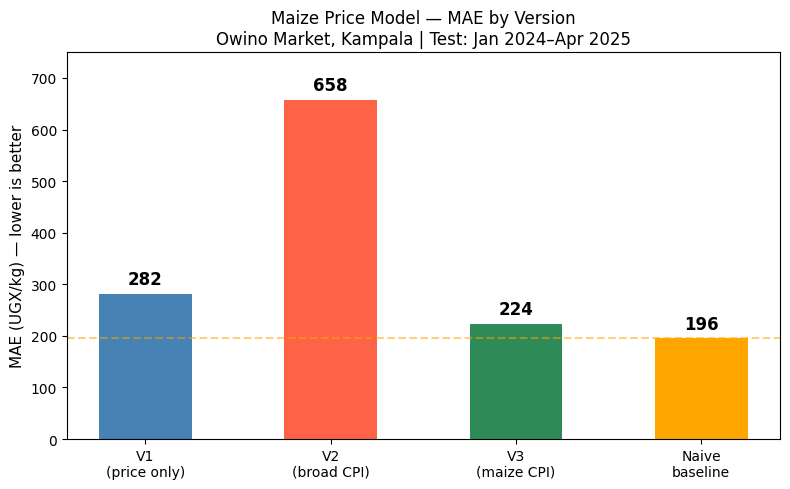

Saved → model_comparison.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

models = ["V1\n(price only)", "V2\n(broad CPI)", "V3\n(maize CPI)", "Naive\nbaseline"]
maes = [282, 658, 224, 196]
colors = ["steelblue", "tomato", "seagreen", "orange"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, maes, color=colors, width=0.5)

# Add value labels on bars
for bar, mae in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{mae}", ha="center", va="bottom", fontweight="bold", fontsize=12)

ax.axhline(y=196, color="orange", linestyle="--", alpha=0.5)
ax.set_ylabel("MAE (UGX/kg) — lower is better", fontsize=11)
ax.set_title("Maize Price Model — MAE by Version\nOwino Market, Kampala | Test: Jan 2024–Apr 2025", fontsize=12)
ax.set_ylim(0, 750)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Saved → model_comparison.png")
